<a href="https://colab.research.google.com/github/DymaStar/Olist_Analytics_DTA_2026_DS/blob/main/notebook/olist_predict_DS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 3. Python: Simple Forecast and Recommendations

In [138]:
# Імпорт бібліотек
import pandas as pd
import matplotlib.pyplot as plt

# Модель лінійної регресії
from sklearn.linear_model import LinearRegression

# Розбиття даних на тренувальну та тестову вибірки
from sklearn.model_selection import train_test_split

# Фіксуємо випадковість для відтворюваності результатів
RANDOM_STATE = 42

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Посилання на CSV-файл
FILE_IN = "https://raw.githubusercontent.com/DymaStar/Olist_Analytics_DTA_2026_DS/refs/heads/main/data/main_sales_reg.csv"

In [139]:
# Завантаження CSV у DataFrame
df = pd.read_csv(FILE_IN)

# Перегляд перших 5 рядків
df.head()

,order_id,order_purchase_t,ym,customer_state,category_en,price,freight_value,payment_method,review_score,region
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,credit_card,4.0,Southeast
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,voucher,4.0,Southeast
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,voucher,4.0,Southeast
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07,BA,perfumery,118.70,22.76,boleto,4.0,Northeast
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08,GO,auto,159.90,19.22,credit_card,5.0,Central-West


In [140]:
# Загальна інформація про таблицю
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115723 entries, 0 to 115722
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          115723 non-null  object 
 1   order_purchase_t  115723 non-null  object 
 2   ym                115723 non-null  object 
 3   customer_state    115723 non-null  object 
 4   category_en       114062 non-null  object 
 5   price             115723 non-null  float64
 6   freight_value     115723 non-null  float64
 7   payment_method    115720 non-null  object 
 8   review_score      114862 non-null  float64
 9   region            115723 non-null  object 
dtypes: float64(3), object(7)
memory usage: 8.8+ MB


In [141]:
# Перевіряємо кількість пропущених значень у кожному стовпці
df.isna().sum()

,0
order_id,0
order_purchase_t,0
ym,0
customer_state,0
category_en,1661
price,0
freight_value,0
payment_method,3
review_score,861
region,0


In [142]:
# Сортуємо дані за стовпцем ym
# Оновлюємо індекси після сортування
df = df.sort_values("ym").reset_index(drop=True)

# Виводимо кількість рядків
print("Month all:", len(df))

# Переглядаємо перші 5 рядків
df.head()

Month all: 115723


,order_id,order_purchase_t,ym,customer_state,category_en,price,freight_value,payment_method,review_score,region
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-09,SP,health_beauty,44.99,2.83,NaN,1.0,Southeast
1,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-09,SP,health_beauty,44.99,2.83,NaN,1.0,Southeast
2,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-09,SP,health_beauty,44.99,2.83,NaN,1.0,Southeast
3,6ef172eee30cfbfa01516ce2eb2ee68f,2016-10-07 11:37:12,2016-10,SP,telephony,18.90,10.96,boleto,5.0,Southeast
4,0c22166d9f7e5761e397affa5af438c7,2016-10-09 22:31:44,2016-10,CE,health_beauty,90.00,26.89,credit_card,5.0,Northeast


In [143]:
# ==========================================
# Готуємо дані для прогнозування ціни
# ==========================================

# Залишаємо тільки період 2017-01 ... 2018-08
df_lr = df[
    (df.ym >= "2017-01") &
    (df.ym <= "2018-08")
].reset_index(drop=True)

# Залишаємо лише потрібні колонки
df_lr = df_lr[["ym", "price"]]

# Перевіряємо, скільки записів залишилося
print("Orders (Day) in process:", len(df_lr))

# Переглядаємо перші 5 рядків
df_lr.head()

Orders (Day) in process: 115385


,ym,price
0,2017-01,44.60
1,2017-01,16.90
2,2017-01,99.90
3,2017-01,21.99
4,2017-01,39.00


In [144]:
# Перевіряємо кількість пропущених значень у кожному стовпці
df_lr.isna().sum()

,0
ym,0
price,0


In [145]:
# Групуємо дані за місяцями
# Обчислюємо сумарний дохід за кожен місяць
df_lr = (
    df_lr
    .groupby("ym")
    .agg(
        revenue=("price", "sum")
    )
    # Повертаємо ym із індексу у звичайну колонку
    .reset_index()
)

# Переглядаємо перші 5 рядків
df_lr.head()

,ym,revenue
0,2017-01,121380.81
1,2017-02,247186.84
2,2017-03,382971.99
3,2017-04,361697.63
4,2017-05,532057.67


In [146]:
type(df_lr)

pandas.core.frame.DataFrame

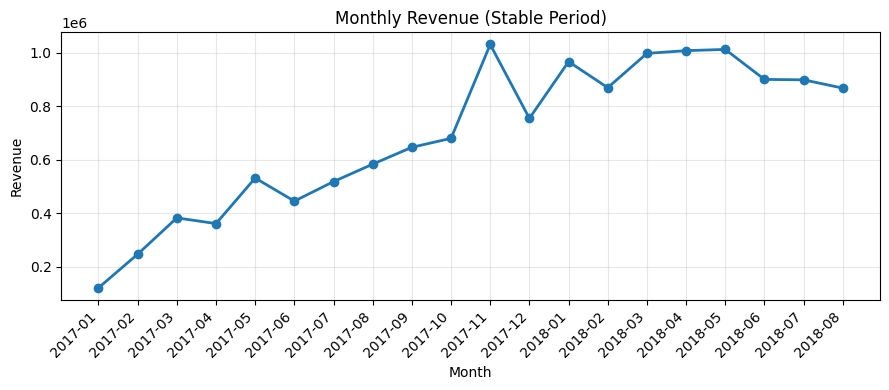

In [147]:
# Створюємо фігуру для побудови графіка
plt.figure(figsize=(9, 4))

# Будуємо лінійний графік зміни місячного доходу
plt.plot(
    df_lr["ym"],
    df_lr["revenue"],
    marker="o",
    linewidth=2,
    label="Monthly revenue"
)

# Повертаємо підписи місяців для кращої читабельності
plt.xticks(rotation=45, ha="right")

# Додаємо назву графіка
plt.title("Monthly Revenue (Stable Period)")

# Підписуємо осі
plt.xlabel("Month")
plt.ylabel("Revenue")

# Додаємо сітку для полегшення аналізу
plt.grid(alpha=0.3)

# Автоматично підганяємо розташування елементів
plt.tight_layout()

# Відображаємо графік
plt.show()

In [148]:
# Створюємо числову часову ознаку (t)
# Вона буде використовуватися як незалежна змінна
# для побудови моделі лінійної регресії.
df_lr["t"] = range(len(df_lr))

# Переглядаємо перші 5 рядків оновленої таблиці
df_lr.head()

,ym,revenue,t
0,2017-01,121380.81,0
1,2017-02,247186.84,1
2,2017-03,382971.99,2
3,2017-04,361697.63,3
4,2017-05,532057.67,4


In [149]:


# ==========================================
# Linear Regression Forecast
# ==========================================

# Ознака (час)
X = df_lr[["t"]]

# Цільова змінна (дохід)
y = df_lr["revenue"]

# Розділяємо дані на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Навчаємо модель
model = LinearRegression().fit(X_train, y_train)

# Індекс наступного місяця
next_index = len(df_lr)

# Прогноз для тестових даних
y_pred = model.predict(X_test)

# Прогноз доходу на наступний місяць
forecast = model.predict(
    pd.DataFrame({"t": [next_index]})
)[0]

# Виводимо результати
print(f"Predict revenue for next month: R${forecast:,.0f}")
print(f"Average growth for month: R${model.coef_[0]:,.0f}")

print("-" * 15)

print(f"MAE: R${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: R${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"Predict accuracy (R2): {r2_score(y_test, y_pred):.1%}")

print("-" * 15)

print(
    f"Predict revenue for next month: "
    f"R${forecast:,.0f} ± {mean_absolute_error(y_test, y_pred):,.0f}"
)

Predict revenue for next month: R$1,109,031
Average growth for month: R$37,963
---------------
MAE: R$138,100
RMSE: R$148,958
Predict accuracy (R2): 85.4%
---------------
Predict revenue for next month: R$1,109,031 ± 138,100


In [150]:
# ==========================================
# Average revenue by month
# ==========================================

# Створюємо окремий стовпець лише з номером місяця
df_lr["month"] = df_lr["ym"].str[-2:]

# Обчислюємо середній дохід для кожного місяця
season = (
    df_lr
    .groupby("month")["revenue"]
    .mean()
    .round(0)
)

# Виводимо результати
print("Average revenue by month:")
print(season.sort_values(ascending=False))

Average revenue by month:
month
11    1031580.0
05     772613.0
12     755290.0
08     726158.0
07     709089.0
03     690642.0
04     685111.0
10     680569.0
06     673338.0
09     647053.0
02     558669.0
01     544393.0
Name: revenue, dtype: float64
